## Exercise 1: Identify the Target Variable and Related KPIs from the Given Data for the Business Problem

In [40]:
from nltk.app.nemo_app import colors
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks")

In [41]:
df = pd.read_csv('bank.csv', sep=';')
df.head(5)
print(df.shape)
df.head(5)
df.info()
df.describe()

(4521, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [42]:
count_number_susbc = df["y"].astype("string").value_counts()
sns.barplot(x = count_number_susbc.index, y=count_number_susbc.values)
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [43]:
# histogram for age (using matplotlib)
plt.hist(df['age'], color = 'grey', edgecolor = 'black', bins = int(180/5))

(array([  7.,  16.,  44., 121., 197., 247., 423., 417., 180., 349., 289.,
        277., 256., 217., 227., 226., 192.,  86., 165., 164., 176., 118.,
         23.,  15.,  15.,   7.,   6.,  13.,  10.,   9.,   8.,   7.,   7.,
          4.,   1.,   2.]),
 array([19.        , 20.88888889, 22.77777778, 24.66666667, 26.55555556,
        28.44444444, 30.33333333, 32.22222222, 34.11111111, 36.        ,
        37.88888889, 39.77777778, 41.66666667, 43.55555556, 45.44444444,
        47.33333333, 49.22222222, 51.11111111, 53.        , 54.88888889,
        56.77777778, 58.66666667, 60.55555556, 62.44444444, 64.33333333,
        66.22222222, 68.11111111, 70.        , 71.88888889, 73.77777778,
        75.66666667, 77.55555556, 79.44444444, 81.33333333, 83.22222222,
        85.11111111, 87.        ]),
 <BarContainer object of 36 artists>)

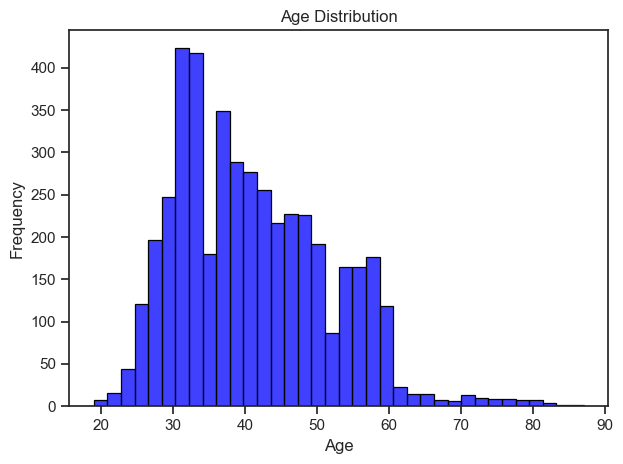

In [46]:
# histogram for age (using seaborn)
sns.histplot(
    df['age'],
    kde=False,
    bins=int(180/5),
    color = 'blue',
    edgecolor='black'
)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

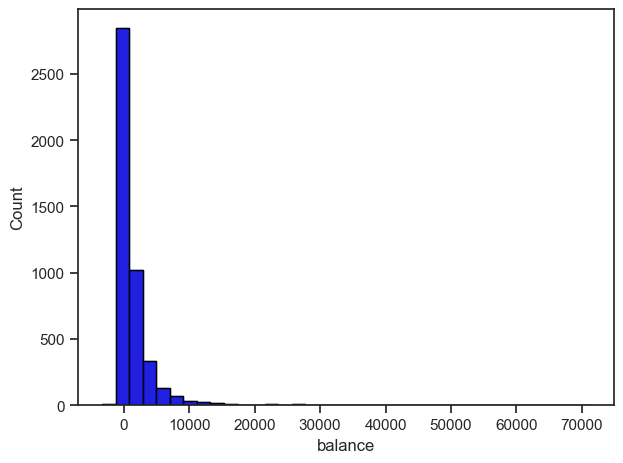

In [47]:
plt.hist(df['balance'], color = 'grey', edgecolor = 'black', bins = int(180/5))

sns.histplot(
    df['balance'],
    kde=False,
    bins=int(180/5),
    color = 'blue',
    edgecolor='black'
)
plt.tight_layout()
plt.show()

In [48]:
count_number_susbc = df["education"].astype("string").value_counts()
sns.barplot(x=count_number_susbc.index, y=count_number_susbc.values)
df['education'].value_counts()

education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64

In [49]:
count_number_susbc = df["month"].astype("string").value_counts()
sns.barplot(count_number_susbc.index)
df['education'].value_counts()

education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64

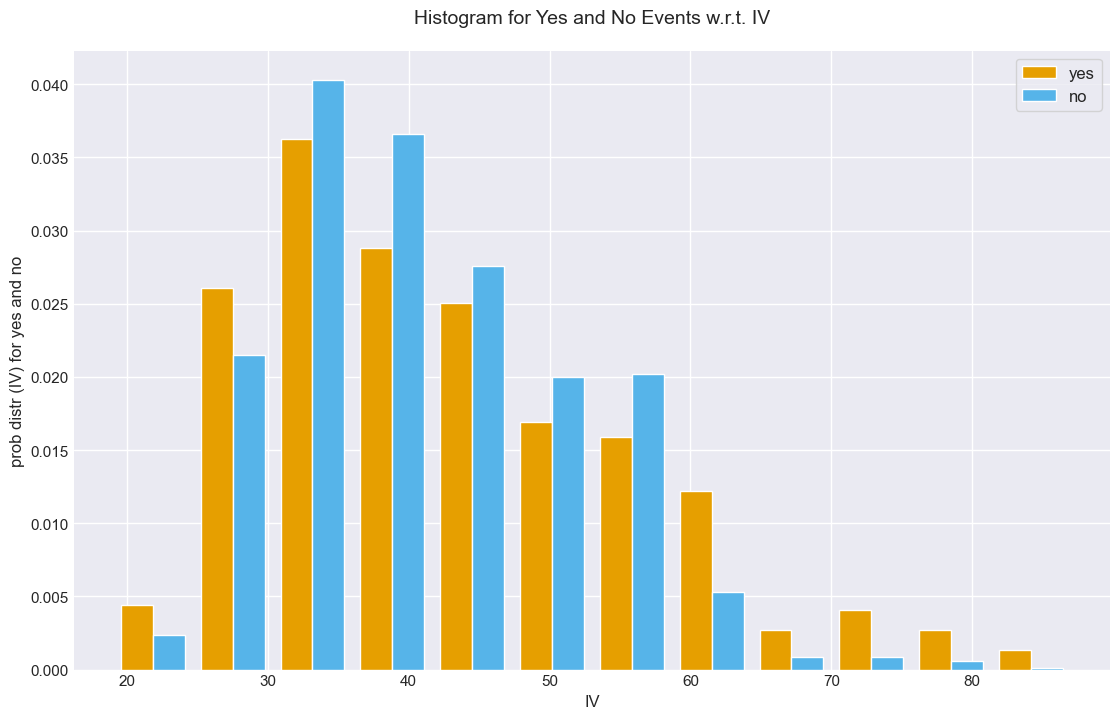

In [52]:
x1 = list(df[df['y'] == 'yes']['age'])
x2 = list(df[df['y'] == 'no']['age'])
colors = ['#E69F00', '#56B4E9']
names = ['yes', 'no']

plt.figure(figsize=(12, 8))

plt.hist([x1, x2], bins = int(180/15), density=True, color = colors, label=names)

plt.legend(loc='best', frameon=True, fontsize=12)
plt.xlabel('IV', fontsize=12)
plt.ylabel('prob distr (IV) for yes and no', fontsize=12)
plt.title('Histogram for Yes and No Events w.r.t. IV', fontsize=14, pad=20)
plt.tight_layout(pad=3.0)
plt.show()

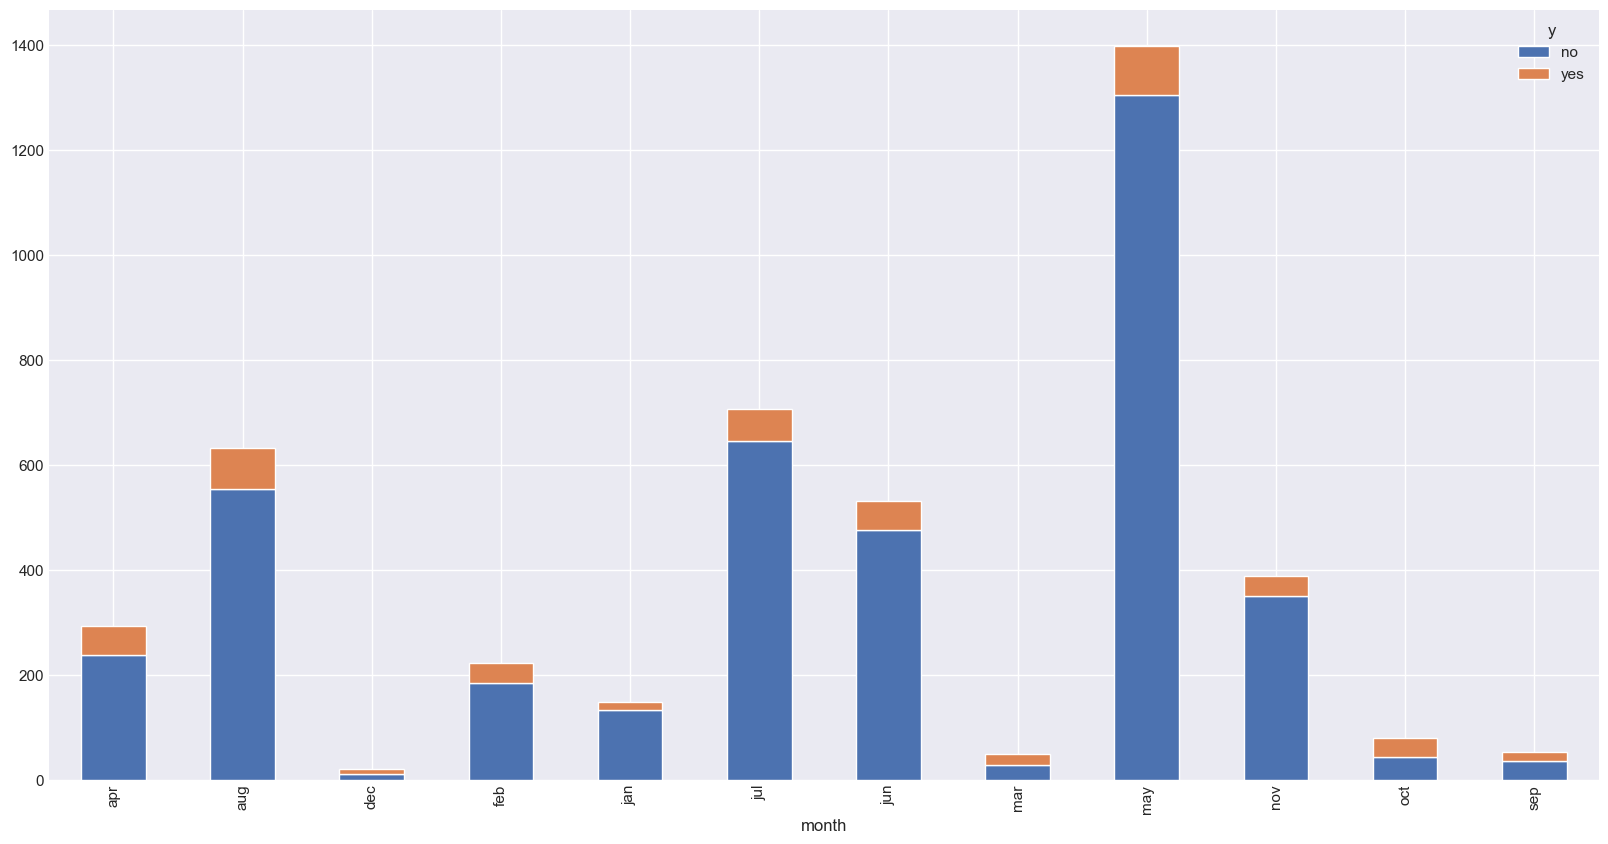

In [53]:
df.groupby(["month", "y"]).size().unstack().plot(kind='bar', stacked=True, figsize=(20,10))
plt.show()